In [216]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import copy

from pathlib import Path
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV,GroupKFold
from lime.lime_tabular import LimeTabularExplainer

from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import pandas as pd

In [256]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

In [183]:
class ActivityClassifier:

    def __init__(self, dataset, outer_splits):

        self.dataset = dataset.dropna(subset=["vo2_mean"]).copy()

        self.outer_splits = outer_splits

        self.HR_FEATURES = [
            "zephyr_std",
            "zephyr_mean",
            "HRR_percent",
            "hrv_mean",
            "hrv_std"
        ]

        self.IMU_FEATURES = [
            "acc_mag__maximum",
            "acc_mag__variance",
            "gyro_mag__mean",
            "gyro_mag__variance"
        ]

        self.RESP_FEATURES = [
            "br_mean",
            "br_std",
            "br_amp_mean",
            "br_amp_std",
            "ventilation_proxy"
        ]

        self.DEMO_FEATURES = [
            "BMI",
            "Age",
            "Weight",
            "Height",
            "Gender"
        ]

        self.FEATURE_SETS = {
            "HR_IMU": self.HR_FEATURES + self.IMU_FEATURES,

            "HR_IMU_RESP":
                self.HR_FEATURES +
                self.IMU_FEATURES +
                self.RESP_FEATURES,

            "IMU_RESP":
                self.IMU_FEATURES +
                self.RESP_FEATURES,

            "ALL_without_HR":
                self.IMU_FEATURES +
                self.RESP_FEATURES +
                self.DEMO_FEATURES,

            "ALL":
                self.HR_FEATURES +
                self.IMU_FEATURES +
                self.RESP_FEATURES +
                self.DEMO_FEATURES
        }


        # Random Forest activity classifier grid

        self.PARAM_GRID = {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 5]
        }

        self.predictions = {}

        self.tuning_results = []

    
    def run(self):

        X_all = self.dataset
        y_activity = self.dataset["activity"]
        groups = self.dataset["participant"]

        for feature_name, features in self.FEATURE_SETS.items():

            print(
                f"\nActivity classification: "
                f"{feature_name}"
            )

            X = X_all[features]

            # OUTER LOSO
            for fold, (train_idx, test_idx) in enumerate(
                            self.outer_splits
                        ):

                X_train = X.iloc[train_idx]
                X_test = X.iloc[test_idx]

                y_train = y_activity.iloc[train_idx]
                y_test = y_activity.iloc[test_idx]

                groups_train = groups.iloc[train_idx]

                test_participant = groups.iloc[test_idx].iloc[0]

                
                # Encode activity
                encoder = LabelEncoder()

                y_train_encoded = encoder.fit_transform(
                    y_train
                )

                y_test_encoded = encoder.transform(
                    y_test
                )

               
                # Activity classifier pipeline

                pipeline = Pipeline([
                    (
                        "scaler",
                        StandardScaler()
                    ),
                    (
                        "model",
                        RandomForestClassifier(
                            random_state=42,
                            n_jobs=1
                        )
                    )
                ])

                # INNER GROUP CV
                inner_cv = GroupKFold(
                    n_splits=4
                )

                search = GridSearchCV(
                    estimator=pipeline,
                    param_grid=self.PARAM_GRID,
                    scoring="accuracy",
                    cv=inner_cv,
                    n_jobs=-1,
                    refit=True
                )

                # Hyperparameter tuning
                search.fit(
                    X_train,
                    y_train_encoded,
                    groups=groups_train
                )

                best_model = search.best_estimator_

                pred_activity_train = (
                    best_model.predict(X_train)
                )

                pred_activity_test = (
                    best_model.predict(X_test)
                )

                test_accuracy = accuracy_score(
                    y_test_encoded,
                    pred_activity_test
                )


                key = (
                    feature_name,
                    fold
                )

                self.predictions[key] = {
                    "train_idx": train_idx,
                    "test_idx": test_idx,
                    "pred_train": pred_activity_train,
                    "pred_test": pred_activity_test,
                    "true_test": y_test_encoded,
                    "true_train": y_train_encoded,
                    "test_accuracy": test_accuracy,
                    "classes": encoder.classes_,
                    "true_test_labels": y_test.values,
                    "pred_test_labels": encoder.inverse_transform(pred_activity_test)
                }
                
                
                # Save tuning information
                self.tuning_results.append({
                    "Feature_Set": feature_name,
                    "Fold": fold,
                    "Test_Participant": test_participant,
                    "Best_Params": search.best_params_,
                    "Best_Inner_Accuracy":
                        search.best_score_
                })

        return self.predictions

In [257]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, dropout = 0.3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [258]:
class TorchMLP:

    def __init__(self, input_dim, lr=0.001, weight_decay=1e-2, dropout = 0.3, epochs=500, patience=10):

        self.input_dim = input_dim
        self.lr = lr
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.patience = patience
        self.dropout = dropout
        
        self.model = SimpleMLP(input_dim, dropout = dropout)

        self.loss_fn = nn.MSELoss()

        
        self.optimizer = optim.Adam(
            self.model.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay  
        )


    def fit(self, X_train, y_train, X_val = None, y_val = None):

        train_losses = []
        val_losses = []
        best_epoch = None
        
        self.y_mean = y_train.mean()
        self.y_std = y_train.std()

        y_train = (y_train - self.y_mean) / self.y_std
        # y_val = (y_val - self.y_mean) / self.y_std

        X_train = torch.tensor(X_train, dtype=torch.float32)
        y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

        #validation
        if X_val is not None and y_val is not None:
            y_val = (y_val - self.y_mean) / self.y_std
            
            X_val = torch.tensor(X_val, dtype=torch.float32)
            y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1,1)

            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                self.optimizer, 
                patience=5, 
                factor=0.5
            )

            best_loss = float("inf")
            counter = 0
            best_model_state = None
    
            for epoch in range(self.epochs):
    
                self.model.train()
                
                preds = self.model(X_train)
                loss = self.loss_fn(preds, y_train)
    
                self.optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(),
                    1.0
                )
                
                self.optimizer.step()
    
                self.model.eval()
                with torch.no_grad():
                    val_preds = self.model(X_val)
                    val_loss = self.loss_fn(val_preds, y_val)
    
                scheduler.step(val_loss.item())
    
                train_losses.append(loss.item())
                val_losses.append(val_loss.item())
    
                epochs_run = epoch+1
    
                #===== EARLY STOPPING =====
                if val_loss.item() < best_loss:
                    best_loss = val_loss.item()
                    counter = 0
                    best_model_state = copy.deepcopy(self.model.state_dict())
    
                    best_epoch = epoch + 1
                    
                else:
                    counter += 1
    
                if counter >= self.patience:
                    break
    
            if best_model_state is not None:
                self.model.load_state_dict(best_model_state)
    
            self.best_epoch = best_epoch
            self.best_val_loss = best_loss

        else:

            #Final training on entire training set
            for epoch in range(self.epochs):

                self.model.train()
    
                preds = self.model(
                    X_train
                )
    
                loss = self.loss_fn(
                    preds,
                    y_train
                )
    
                self.optimizer.zero_grad()
    
                loss.backward()
    
                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(),
                    1.0
                )
    
                self.optimizer.step()
    
                train_losses.append(loss.item())

                self.best_epoch = None
                self.best_val_loss = None


        
        self.train_losses = train_losses
        self.val_losses = val_losses
        self.epochs_run = len(train_losses)
                 
        return train_losses, val_losses, best_epoch

    def predict(self, X):

        X_tensor = torch.tensor(X, dtype=torch.float32)

        self.model.eval()

        with torch.no_grad():
            preds = self.model(X_tensor).squeeze().numpy()

        return preds * self.y_std + self.y_mean

In [259]:
class LOSO_MLP_IG:

    def __init__(self, dataset, outer_splits, activity_predictions):

        self.dataset = dataset.dropna(subset=["vo2_mean"]).copy()
        self.outer_splits = outer_splits
        self.activity_predictions = activity_predictions

        self.results = []
        self.all_preds = []
        self.ig_storage = {}
        self.loss_storage = []
        self.tuning_results = []
        self.lime_storage = {}

        # FEATURE GROUPS
        self.HR_FEATURES = ["zephyr_std", "zephyr_mean", "HRR_percent", "hrv_mean", "hrv_std"]
        
        self.IMU_FEATURES = [
            "acc_mag__maximum",
            "acc_mag__variance",
            "gyro_mag__mean",
            "gyro_mag__variance",
            # "acc_energy__mean",
            #"gyro_energy__mean",

        ]

        self.RESP_FEATURES = [
            "br_mean", "br_std",
            "br_amp_mean", "br_amp_std",
            "ventilation_proxy"
        ]

        self.DEMO_FEATURES = [#"BMI",
                              "Age", "Weight", "Height", "Gender"]

        # FEATURE SETS
        self.FEATURE_SETS = {
            "HR_IMU": self.HR_FEATURES + self.IMU_FEATURES,
            "HR_IMU_RESP": self.HR_FEATURES + self.IMU_FEATURES + self.RESP_FEATURES,
            "IMU_RESP": self.IMU_FEATURES + self.RESP_FEATURES,
            "ALL_without_HR": self.IMU_FEATURES + self.RESP_FEATURES + self.DEMO_FEATURES,
            "ALL": self.HR_FEATURES + self.IMU_FEATURES + self.RESP_FEATURES + self.DEMO_FEATURES
        }

        self.PARAM_GRID = {
            "lr": [0.0005, 0.001],
            "weight_decay": [1e-3, 1e-2],
            "patience": [20, 30],
            "dropout": [0.0, 0.3]
        }



    def run_loso(self, feature_columns, feature_set_name):
        
            X = self.dataset[feature_columns]
            y = self.dataset["vo2_mean"]
            groups = self.dataset["participant"]
            
            for fold, (train_idx, test_idx) in enumerate(self.outer_splits):
            
                X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
                
                groups_train = groups.iloc[train_idx]
                test_participant = groups.iloc[test_idx].iloc[0]


                    
                activity_info = self.activity_predictions[
                    (feature_set_name, fold)
                ]
    
                pred_activity_train = (
                    activity_info["pred_train"]
                )
    
                pred_activity_test = (
                    activity_info["pred_test"]
                )
    
                # TRUE ACTIVITY
                activity_train = (
                    self.dataset.iloc[train_idx]["activity"]
                )
    
                activity_test = (
                    self.dataset.iloc[test_idx]["activity"]
                )
    
                activity_encoder = LabelEncoder()
    
                activity_train_enc = (
                    activity_encoder.fit_transform(
                        activity_train
                    )
                )
    
                activity_test_enc = (
                    activity_encoder.transform(
                        activity_test
                    )
                )

                # BASE DATASET    
                X_train_all = X_train.copy()
                X_test_all = X_test.copy()
    
                # TRUE ACTIVITY DATASET
                X_train_true = X_train.copy()
                X_test_true = X_test.copy()
    
                X_train_true["true_activity"] = (
                    activity_train_enc
                )
    
                X_test_true["true_activity"] = (
                    activity_test_enc
                )
    
                X_train_true = pd.get_dummies(
                    X_train_true,
                    columns=["true_activity"]
                )
    
                X_test_true = pd.get_dummies(
                    X_test_true,
                    columns=["true_activity"]
                )
    
                X_train_true, X_test_true = (
                    X_train_true.align(
                        X_test_true,
                        join="left",
                        axis=1,
                        fill_value=0
                    )
                )
    
                # PREDICTED ACTIVITY DATASET
                X_train_pred = X_train.copy()
                X_test_pred = X_test.copy()
    
                X_train_pred["pred_activity"] = (
                    pred_activity_train
                )
    
                X_test_pred["pred_activity"] = (
                    pred_activity_test
                )
    
                X_train_pred = pd.get_dummies(
                    X_train_pred,
                    columns=["pred_activity"]
                )
    
                X_test_pred = pd.get_dummies(
                    X_test_pred,
                    columns=["pred_activity"]
                )
    
                X_train_pred, X_test_pred = (
                    X_train_pred.align(
                        X_test_pred,
                        join="left",
                        axis=1,
                        fill_value=0
                    )
                )
    
                # THREE DATASET VERSIONS    
                datasets = {
    
                    feature_set_name:
                        (
                            X_train_all,
                            X_test_all
                        ),
    
                    f"{feature_set_name}_TRUE_ACTIVITY":
                        (
                            X_train_true,
                            X_test_true
                        ),
    
                    f"{feature_set_name}_PRED_ACTIVITY":
                        (
                            X_train_pred,
                            X_test_pred
                        )
                }

              
                # training for each version of dataset
                for version, (Xtr_full, X_te) in datasets.items():

                    #group validation
                    gkf = GroupKFold(n_splits=2)
                        
                        
                    best_val_loss = float("inf")
                    
                    best_params = None
                    best_epoch = None
                    
                    best_tuning_train_loss = None
                    best_tuning_val_loss = None
                                        
                   
                    # LOOP OVER HYPERPARAMETERS 
                    for lr in self.PARAM_GRID["lr"]:
                    
                        for weight_decay in self.PARAM_GRID["weight_decay"]:
                    
                            for patience in self.PARAM_GRID["patience"]:
                    
                                for dropout in self.PARAM_GRID["dropout"]:
                    
                                    # print(
                                    #     f"Testing: "
                                    #     f"lr={lr}, "
                                    #     f"weight_decay={weight_decay}, "
                                    #     f"patience={patience}, "
                                    #     f"dropout={dropout}"
                                    # )
                    
                    
                                    inner_val_losses = []
                                    inner_train_losses = []
                                    inner_best_epochs = []
                                    
                                    inner_train_curves = []
                                    inner_val_curves = []
                    

                                    # 4 INNER FOLDS
                                    for inner_fold, (
                                        train_idx_inner,
                                        val_idx_inner
                                    ) in enumerate(
                                        gkf.split(
                                            Xtr_full,
                                            y_train,
                                            groups_train
                                        )
                                    ):
                    
                                        X_tr = Xtr_full.iloc[
                                            train_idx_inner
                                        ]
                    
                                        X_val = Xtr_full.iloc[
                                            val_idx_inner
                                        ]
                    
                                        y_tr = y_train.iloc[
                                            train_idx_inner
                                        ]
                    
                                        y_val = y_train.iloc[
                                            val_idx_inner
                                        ]
                    
    
                                        # SCALE
                                        scaler_inner = StandardScaler()
                    
                                        X_tr_scaled = scaler_inner.fit_transform(
                                            X_tr
                                        )
                    
                                        X_val_scaled = scaler_inner.transform(
                                            X_val
                                        )
                    
 
                                        # New model                 
                                        tuning_model = TorchMLP(
                    
                                            input_dim=X_tr.shape[1],
                    
                                            lr=lr,
                    
                                            weight_decay=weight_decay,
                    
                                            dropout=dropout,
                    
                                            epochs=500,
                    
                                            patience=patience
                                        )
                    
                    
                                        (
                                            train_loss_tune,
                                            val_loss_tune,
                                            best_epoch_tune
                                        ) = tuning_model.fit(
                    
                                            X_tr_scaled,
                    
                                            y_tr,
                    
                                            X_val_scaled,
                    
                                            y_val
                                        )

                                        inner_train_curves.append(train_loss_tune)
                                        inner_val_curves.append(val_loss_tune)
                    
                                        # BEST LOSS FOR THIS INNER FOLD
                                        fold_best_val_loss = min(
                                            val_loss_tune
                                        )
                    
                                        best_index = (
                                            val_loss_tune.index(
                                                fold_best_val_loss
                                            )
                                        )
                    
                                        fold_best_train_loss = (
                                            train_loss_tune[
                                                best_index
                                            ]
                                        )
                    
                    
                                        inner_val_losses.append(
                                            fold_best_val_loss
                                        )
                    
                                        inner_train_losses.append(
                                            fold_best_train_loss
                                        )
                    
                                        inner_best_epochs.append(
                                            best_epoch_tune
                                        )
                    

                                    # MEAN PERFORMANCE ACROSS 4 INNER FOLDS                    
                                    mean_val_loss = np.mean(
                                        inner_val_losses
                                    )
                    
                                    mean_train_loss = np.mean(
                                        inner_train_losses
                                    )
                    
                                    mean_best_epoch = int(
                                        round(
                                            np.mean(
                                                inner_best_epochs
                                            )
                                        )
                                    )
                    
                    

                                    # SELECT BEST HYPERPARAMETERS                    
                                    if mean_val_loss < best_val_loss:
                    
                                        best_val_loss = mean_val_loss
                    
                                        best_params = {
                    
                                            "lr": lr,
                    
                                            "weight_decay":
                                                weight_decay,
                    
                                            "patience":
                                                patience,
                    
                                            "dropout":
                                                dropout
                                        }
                    
                                        best_epoch = (
                                            mean_best_epoch
                                        )
                    
                                        best_tuning_train_loss = (
                                            mean_train_loss
                                        )
                    
                                        best_tuning_val_loss = (
                                            mean_val_loss
                                        )

                                        best_train_curves = inner_train_curves
                                        best_val_curves = inner_val_curves


                    # SAVE TUNING INFORMATION
                    self.tuning_results.append({
    
                        "Feature_Set": version,
    
                        "Fold": fold,
    
                        "Test_Participant":
                            test_participant,
    
                        "Best_Params":
                            best_params,
    
                        "Best_Inner_Val_Loss":
                            best_val_loss,

                        "Best_Epoch": best_epoch
                    })
                        
                    # model = TorchMLP(input_dim=X_tr.shape[1], epochs=500)
                    # train_loss, val_loss = model.fit(X_tr_scaled, y_tr, X_val_scaled, y_val)


                    self.loss_storage.append({

                        "Feature_Set": version,
    
                        "Fold": fold,
    
                        "Train_Loss": best_train_curves,
    
                        "Val_Loss": best_val_curves,
                        "Test_Participant": test_participant,
                        "Best_Params": best_params
                        
                    })


                # Retrain using ALL outer training participants

                    final_scaler = StandardScaler()

                    X_train_scaled = (
                        final_scaler.fit_transform(
                            Xtr_full
                        )
                    )
    
                    X_test_scaled = (
                        final_scaler.transform(
                            X_te
                        )
                    )
                    
                 # FINAL MODEL
                    final_model = TorchMLP(
    
                        input_dim=Xtr_full.shape[1],
    
                        lr=best_params["lr"],
    
                        weight_decay=
                            best_params["weight_decay"],
                        
                        dropout=best_params["dropout"],
                        
                        epochs=best_epoch,
    
                        patience=
                            best_params["patience"]
                    )

                    
                    final_train_losses = (
                        final_model.fit(
                            X_train_scaled,
                            y_train
                        )
                    )
                        

                    #predictions
                    y_pred = final_model.predict(
                        X_test_scaled
                    )
    
                    y_pred_train = final_model.predict(
                        X_train_scaled
                    )

                    all_features = list(Xtr_full.columns)

                    # Store LIME information
                    if version not in self.lime_storage:
                        self.lime_storage[version] = []
                    
                    self.lime_storage[version].append({
                        "X_train": X_train_scaled,
                        "X_test": X_test_scaled,
                        "features": all_features,
                        "model": final_model,
                        "predict_fn": final_model.predict,
                        "activity": self.dataset.iloc[test_idx]["activity"].values,
                        "Test_Participant": test_participant,
                        "Fold": fold
                    })
                    
                    # Metrics
                    self.results.append({
                        "Feature_Set": version,
                        # "Epochs": model.epochs_run,
                        "Fold": fold,
                        "Test_Participant": test_participant,
                        "Train_R2": r2_score(y_train, y_pred_train),
                        "Test R2": r2_score(y_test, y_pred),
                        "MAE": mean_absolute_error(y_test, y_pred),
                        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
                    })
                    
                    # IG
                    all_features = list(Xtr_full.columns)
                    ig = IntegratedGradients(final_model.model)
                    ig_values = ig.explain(pd.DataFrame(X_test_scaled, columns=all_features))
                    
                    X_eval = pd.DataFrame(X_test_scaled, columns=all_features)
                    X_eval["activity"] = self.dataset.iloc[test_idx]["activity"].values
                    
                    # Initialize storage per feature set
                    if version not in self.ig_storage:
                        self.ig_storage[version] = {
                            "ig": [],
                            "X": []
                        }
                    
                    # Store
                    self.ig_storage[version]["ig"].append(ig_values)
                    self.ig_storage[version]["X"].append(X_eval)
                    
                    for i in range(len(y_test)):
                        self.all_preds.append({
                            "Feature_Set": version,
                            "Fold": fold,
                            "y_true": y_test.iloc[i],
                            "y_pred": y_pred[i],
                            "Test_Participant": test_participant,
                        })


    def run(self):
    
        for feature_set_name, features in (
            self.FEATURE_SETS.items()
        ):

            print(f"\nRunning feature set: {feature_set_name}")
            
            self.run_loso(
                feature_columns=features,
                feature_set_name=feature_set_name
            )
        
        return pd.DataFrame(self.results)
        

In [204]:
class IntegratedGradients:

    def __init__(self, model, steps=50):
        self.model = model
        self.steps = steps

    def explain(self, X):

        X_tensor = torch.tensor(X.values, dtype=torch.float32)
        baseline = torch.zeros_like(X_tensor)

        attributions = []

        for i in range(X_tensor.shape[0]):

            x = X_tensor[i].unsqueeze(0)
            b = baseline[i].unsqueeze(0)

            scaled_inputs = [
                b + (k/self.steps)*(x - b)
                for k in range(self.steps+1)
            ]

            grads = []

            for inp in scaled_inputs:
                inp.requires_grad = True

                output = self.model(inp)
                self.model.zero_grad()
                output.backward()

                grads.append(inp.grad.detach())

            avg_grads = torch.stack(grads).mean(dim=0)
            ig = (x - b) * avg_grads

            attributions.append(ig.squeeze().numpy())

        return np.array(attributions)

In [245]:
class IGVisualizer:

    def __init__(self, experiment):
        self.exp = experiment
        self.ig_all = None
        self.X_all = None
        self.X_features = None
        self.feature_set = None


    # Load feature set
    def set_feature_set(self, feature_set):

        self.feature_set = feature_set

        self.ig_all = np.vstack(
            self.exp.ig_storage[feature_set]["ig"]
        )

        self.X_all = pd.concat(
            self.exp.ig_storage[feature_set]["X"]
        ).reset_index(drop=True)

        self.X_features = self.X_all.drop(columns=["activity"], errors="ignore")

        print(f"Loaded feature set: {feature_set}")
        print(f"Shape: {self.X_features.shape}")


    # Feature Importance
    def plot_importance(self, top_n=10, save_path = None):

        importance = np.abs(self.ig_all).mean(axis=0)

        df = pd.DataFrame({
            "feature": self.X_features.columns,
            "importance": importance
        }).sort_values("importance", ascending=False)

        true_imp = df[
            df["feature"].str.startswith("true_activity")
        ]["importance"].sum()
        
        pred_imp = df[
            df["feature"].str.startswith("pred_activity")
        ]["importance"].sum()
        
        # remove one-hot activity columns
        df = df[
            ~df["feature"].str.startswith("true_activity")
        ]
        
        df = df[
            ~df["feature"].str.startswith("pred_activity")
        ]
        
        # add aggregated rows
        rows = []
        
        if true_imp > 0:
            rows.append({
                "feature": "TRUE_ACTIVITY",
                "importance": true_imp
            })
        
        if pred_imp > 0:
            rows.append({
                "feature": "PRED_ACTIVITY",
                "importance": pred_imp
            })
        
        if len(rows) > 0:
            df = pd.concat(
                [df, pd.DataFrame(rows)],
                ignore_index=True
            )
            
        df = df.sort_values(
            "importance",
            ascending=False
        )

        fig, ax = plt.subplots(figsize=(8, 7))
        sns.barplot(data=df.head(top_n), x="importance", y="feature")
    
        ax.set_xlabel(
            "Importance",
            fontsize=16
        )
    
        ax.set_ylabel(
            "Feature",
            fontsize=16
        )
    
        ax.tick_params(
            axis="both",
            labelsize=16
        )
    
        plt.tight_layout()
    
        if save_path is not None:
            plt.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()
        return df.head(top_n)


    # Dependence Plot
    def plot_dependence(self, feature):

        if feature not in self.X_features.columns:
            print(f"{feature} not in feature set")
            return

        idx = self.X_features.columns.get_loc(feature)

        plt.figure(figsize=(6,5))

        plt.scatter(
            self.X_features[feature],
            self.ig_all[:, idx],
            c=self.X_all["activity"].astype("category").cat.codes,
            cmap="viridis",
            alpha=0.7
        )

        plt.colorbar(label="Activity")
        plt.xlabel(feature)
        plt.ylabel(f"IG value ({feature})")
        plt.title(f"Dependence: {feature}")
        plt.show()

    
    # heatmap w.r.t to each activity
    def plot_activity_heatmap(self, top_n=10, mode = "mean"):

        importance = np.abs(self.ig_all).mean(axis=0)
    
        df_imp = pd.DataFrame({
            "feature": self.X_features.columns,
            "importance": importance
        })
        
        # Find one-hot activity columns
        true_cols = [
            c for c in self.X_features.columns
            if c.startswith("true_activity")
        ]
        
        pred_cols = [
            c for c in self.X_features.columns
            if c.startswith("pred_activity")
        ]
        
        # Aggregate importance
        true_imp = df_imp[
            df_imp["feature"].isin(true_cols)
        ]["importance"].sum()
        
        pred_imp = df_imp[
            df_imp["feature"].isin(pred_cols)
        ]["importance"].sum()
        
        # Remove one-hot rows
        df_imp = df_imp[
            ~df_imp["feature"].isin(true_cols + pred_cols)
        ]
        
        # Add aggregated rows
        rows_to_add = []
        
        if len(true_cols) > 0:
            rows_to_add.append({
                "feature": "TRUE_ACTIVITY",
                "importance": true_imp
            })
        
        if len(pred_cols) > 0:
            rows_to_add.append({
                "feature": "PRED_ACTIVITY",
                "importance": pred_imp
            })
        
        df_imp = pd.concat(
            [df_imp, pd.DataFrame(rows_to_add)],
            ignore_index=True
        )
        
        top_features = (
            df_imp
            .sort_values("importance", ascending=False)
            .head(top_n)["feature"]
        )
    
        rows = []
    
        for feat in top_features:
            
            if feat == "TRUE_ACTIVITY":
            
                idxs = [
                    self.X_features.columns.get_loc(c)
                    for c in true_cols
                ]
            
                importance_values = np.abs(
                    self.ig_all[:, idxs]
                ).sum(axis=1)
            
            elif feat == "PRED_ACTIVITY":
            
                idxs = [
                    self.X_features.columns.get_loc(c)
                    for c in pred_cols
                ]
                
                importance_values = np.abs(
                    self.ig_all[:, idxs]
                ).sum(axis=1)
            
            else:
            
                idx = self.X_features.columns.get_loc(feat)
                
                importance_values = np.abs(
                    self.ig_all[:, idx]
                )
                
            temp = pd.DataFrame({
                "activity": self.X_all["activity"],
                "importance": importance_values
            })                            

            if mode == "mean":
                grp = (
                    temp.groupby("activity")["importance"]
                    .mean()
                )
            if mode == "std":
                grp = (
                    temp.groupby("activity")["importance"]
                    .std()
                )

            for act, val in grp.items():
    
                rows.append({
                    "feature": feat,
                    "activity": act,
                    "importance": val
                })
    
        heat_df = pd.DataFrame(rows)
    
        pivot = heat_df.pivot(
            index="feature",
            columns="activity",
            values="importance"
        )
    
        plt.figure(figsize=(10,6))
    
        sns.heatmap(
            pivot,
            annot=True,
            cmap="viridis"
        )

        if mode == "mean":
            title = "Feature Importance"

        elif mode == "std":
            title = "Standard Deviation(|IG|)"
    
        plt.title(
            f"{title} Across Activities ({self.feature_set})"
        )
    
        plt.show()


In [321]:
class LIMEAnalyzer:

    def __init__(self, experiment):
        self.exp = experiment



    # Aggregate one-hot encoded activity features
    def aggregate_activity_features(self, obj):

        true_rows = [
            r for r in obj.index
            if str(r).startswith("true_activity_")
        ]

        pred_rows = [
            r for r in obj.index
            if str(r).startswith("pred_activity_")
        ]

        if len(true_rows):

            obj.loc["TRUE_ACTIVITY"] = (
                obj.loc[true_rows].sum(axis=0)
            )

            obj = obj.drop(true_rows)

        if len(pred_rows):

            obj.loc["PRED_ACTIVITY"] = (
                obj.loc[pred_rows].sum(axis=0)
            )

            obj = obj.drop(pred_rows)

        return obj


    # Global LIME importance
    def plot_global_importance(
        self,
        version,
        top_n=10,
        save_path=None
    ):

        rows = []

        items = self.exp.lime_storage[version]

        # Generate LIME explanations for every LOSO fold
        for item in items:

            explainer = LimeTabularExplainer(
                item["X_train"],
                feature_names=item["features"],
                mode="regression",
                random_state=42
            )

            for i in range(len(item["X_test"])):

                exp = explainer.explain_instance(
                    item["X_test"][i],
                    item["predict_fn"],
                    num_features=len(item["features"])
                )

                for feature, weight in exp.as_list():

                    for feat in item["features"]:

                        if feat in feature:

                            rows.append(
                                (feat, abs(weight))
                            )

        df = pd.DataFrame(
            rows,
            columns=["feature", "importance"]
        )

        imp = (
            df.groupby("feature")["importance"]
            .mean()
            .sort_values(ascending=False)
        )

        imp = self.aggregate_activity_features(imp)

        imp = (
            imp
            .sort_values(ascending=False)
            .head(top_n)
            .sort_values()
        )



        # Plot
        fig, ax = plt.subplots(
            figsize=(8, 7)
        )

        imp.plot.barh(
            ax=ax
        )

        ax.set_ylabel(
            "Feature",
            fontsize=16
        )

        ax.tick_params(
            axis="both",
            labelsize=16
        )

        plt.tight_layout()


        if save_path is not None:

            plt.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight"
            )


        plt.show()

        return imp


    # LIME importance across activities
    def plot_activity_heatmap(
        self,
        version,
        top_n=10,
        save_path=None
    ):

        rows = []

        items = self.exp.lime_storage[version]

        # Generate LIME explanations
        for item in items:

            explainer = LimeTabularExplainer(
                item["X_train"],
                feature_names=item["features"],
                mode="regression",
                random_state=42
            )

            for i in range(len(item["X_test"])):

                activity = item["activity"][i]

                exp = explainer.explain_instance(
                    item["X_test"][i],
                    item["predict_fn"],
                    num_features=len(item["features"])
                )

                for feature, weight in exp.as_list():

                    for feat in item["features"]:

                        if feat in feature:

                            rows.append({
                                "activity": activity,
                                "feature": feat,
                                "importance": abs(weight)
                            })


        # Create dataframe
        df = pd.DataFrame(rows)

        # Create activity × feature matrix
        pivot = (
            df.groupby(
                ["feature", "activity"]
            )["importance"]
            .mean()
            .unstack()
        )
        

        # Aggregate activity one-hot features FIRST    
        pivot = self.aggregate_activity_features(
            pivot
        )
        
        

        # Find globally important features AFTER aggregation       
        mean_importance = (
            pivot.mean(axis=1)
            .sort_values(ascending=False)
        )
        
        top_features = (
            mean_importance
            .head(top_n)
            .index
        )
        
        pivot = pivot.loc[top_features]

        


        # Plot
        fig, ax = plt.subplots(
            figsize=(10, 8)
        )

        sns.heatmap(
            pivot,
            annot=True,
            cmap="viridis",
            ax=ax,
            annot_kws={
                "fontsize": 16
            }
        )

        ax.set_title(
            f"Importance Across Activities\n{version}",
            fontsize=16
        )

        ax.set_xlabel(
            "Activity",
            fontsize=16
        )

        ax.set_ylabel(
            "Feature",
            fontsize=16
        )

        ax.tick_params(
            axis="y",
            labelsize=16
        )
        
        plt.setp(
            ax.get_xticklabels(),
            rotation=45,
            ha="right",
            fontsize=16
        )
        

        plt.tight_layout()

        if save_path is not None:

            plt.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight"
            )


        plt.show()



    def plot_activity_sd_heatmap(
        self,
        version,
        top_n=10,
        save_path=None
    ):

        rows = []

        items = self.exp.lime_storage[version]



        # Generate LIME explanations
        for item in items:

            explainer = LimeTabularExplainer(
                item["X_train"],
                feature_names=item["features"],
                mode="regression",
                random_state=42
            )

            for i in range(len(item["X_test"])):

                activity = item["activity"][i]

                exp = explainer.explain_instance(
                    item["X_test"][i],
                    item["predict_fn"],
                    num_features=len(item["features"])
                )

                for feature, weight in exp.as_list():

                    for feat in item["features"]:

                        if feat in feature:

                            rows.append({
                                "activity": activity,
                                "feature": feat,
                                "importance": abs(weight)
                            })



        # Create dataframe
        df = pd.DataFrame(rows)


        # Create activity × feature matrix        
        pivot = (
            df.groupby(
                ["feature", "activity"]
            )["importance"]
            .std()
            .unstack()
        )
        
        

        # Aggregate activity one-hot features FIRST    
        pivot = self.aggregate_activity_features(
            pivot
        )
        
        

        # Find globally important features AFTER aggregation      
        mean_importance = (
            pivot.mean(axis=1)
            .sort_values(ascending=False)
        )
        
        top_features = (
            mean_importance
            .head(top_n)
            .index
        )
        
        pivot = pivot.loc[top_features]


        # Plot
        fig, ax = plt.subplots(
            figsize=(10, 8)
        )

        sns.heatmap(
            pivot,
            annot=True,
            cmap="viridis",
            ax=ax,
            annot_kws={
                "fontsize": 16
            }
        )

        ax.set_title(
            f"Standard Deviation Across Activities\n{version}",
            fontsize=16
        )

        ax.set_xlabel(
            "Activity",
            fontsize=16
        )

        ax.set_ylabel(
            "Feature",
            fontsize=16
        )

        ax.tick_params(
            axis="y",
            labelsize=16
        )
        
        plt.setp(
            ax.get_xticklabels(),
            rotation=45,
            ha="right",
            fontsize=16
        )
        

        plt.tight_layout()

        if save_path is not None:

            plt.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight"
            )


        plt.show()

# For activity classification

In [184]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Results"

dataset = pd.read_csv(DATA_DIR / "window_30s_dataset.csv")

logo = LeaveOneGroupOut()

outer_splits = list(
    logo.split(
        dataset,
        dataset["vo2_mean"],
        dataset["participant"]
    )
)

activity_classifier = ActivityClassifier(
    dataset,
    outer_splits
)

activity_predictions = (
    activity_classifier.run()
)


===== Activity classification: HR_IMU =====


python(92497) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(92498) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(92499) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(92500) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(92501) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(92502) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



===== Activity classification: HR_IMU_RESP =====

===== Activity classification: IMU_RESP =====

===== Activity classification: ALL_without_HR =====

===== Activity classification: ALL =====


# To run EEE

In [260]:
experiment = LOSO_MLP_IG(filtered_dataset, outer_splits, activity_predictions)
results = experiment.run()


Running feature set: HR_IMU

Running feature set: HR_IMU_RESP

Running feature set: IMU_RESP

Running feature set: ALL_without_HR

Running feature set: ALL


In [159]:
summary = (
    results
    .groupby("Feature_Set")[["Train_R2", "Test R2", "MAE", "RMSE"]]
    .mean()
)

summary


,Train_R2,Test R2,MAE,RMSE
Feature_Set,,,,
ALL,0.928508,0.653253,0.678962,0.906932
ALL_PRED_ACTIVITY,0.943422,0.530982,0.658605,0.907573
ALL_TRUE_ACTIVITY,0.955612,0.648916,0.625471,0.845923
ALL_without_HR,0.843717,0.392765,0.837359,1.077138
ALL_without_HR_PRED_ACTIVITY,0.913992,0.237283,0.788508,1.058506
ALL_without_HR_TRUE_ACTIVITY,0.919346,0.505681,0.724406,0.994198
HR_IMU,0.918205,0.618209,0.661429,0.865060
HR_IMU_PRED_ACTIVITY,0.917716,0.606335,0.621936,0.840188
HR_IMU_RESP,0.918594,0.593003,0.697076,0.893678


# Global LIME importance: Initialise LIMEAnalyzer with the trained experiment and call 1.plot_global_importance() specifying the feature-set name, number of features to display,  2.plot_activity_heatmap, 3. plot_activity_sd_heatmap(for standard deviation)

In [325]:
lime = LIMEAnalyzer(experiment)

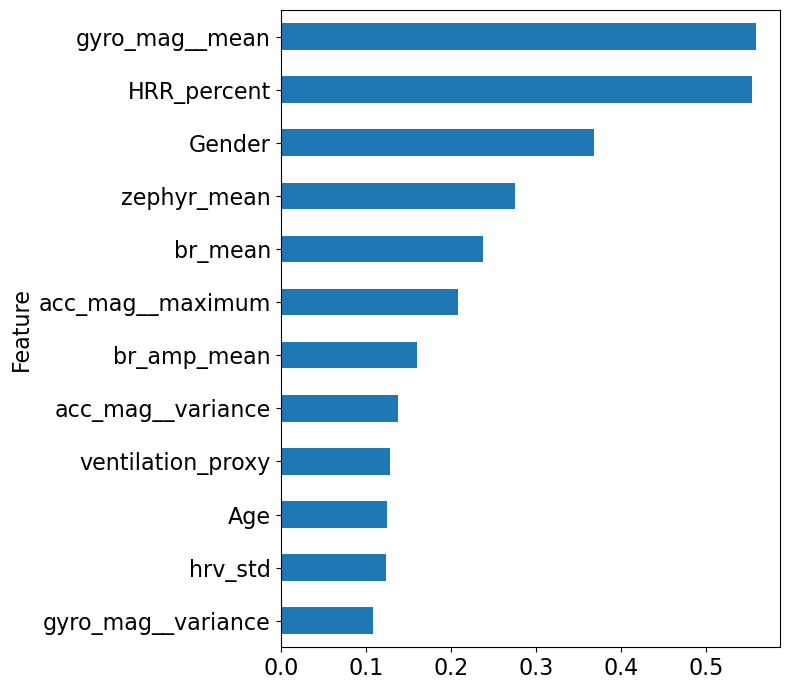

feature
gyro_mag__variance    0.108844
hrv_std               0.123484
Age                   0.125419
ventilation_proxy     0.128307
acc_mag__variance     0.137477
br_amp_mean           0.160040
acc_mag__maximum      0.208615
br_mean               0.238014
zephyr_mean           0.275412
Gender                0.368454
HRR_percent           0.554131
gyro_mag__mean        0.559160
Name: importance, dtype: float64

In [296]:
lime.plot_global_importance(
    version="ALL",
    top_n=12,
    save_path="ALL.png"
)

In [ ]:
lime.plot_activity_heatmap(
    version="ALL",
    top_n = 10
)

In [ ]:
lime.plot_activity_sd_heatmap(
    version="ALL",
    top_n = 10
)

# IG: Initialise IGVisulaizer with the trained experiment, select the desired feature set  and call 1.plot_importance() , 2. plot_activity_heatmap(mode = "mean") (change mode = std, for standard deviation)

In [263]:
viz = IGVisualizer(experiment)

Loaded feature set: HR_IMU_TRUE_ACTIVITY
Shape: (642, 15)


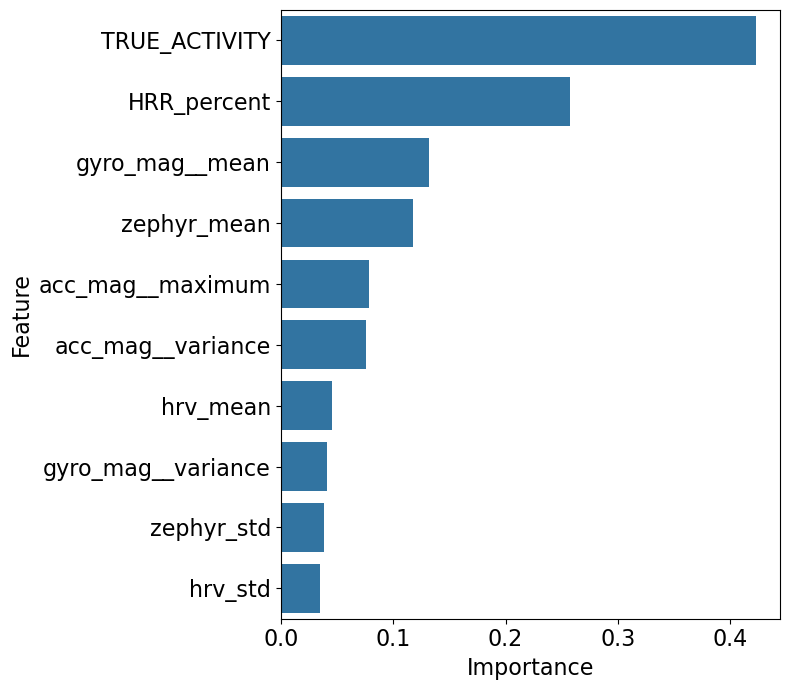

,feature,importance
9,TRUE_ACTIVITY,0.422912
0,HRR_percent,0.257106
1,gyro_mag__mean,0.132003
2,zephyr_mean,0.117727
3,acc_mag__maximum,0.078147
4,acc_mag__variance,0.075902
5,hrv_mean,0.046104
6,gyro_mag__variance,0.041474
7,zephyr_std,0.038229
8,hrv_std,0.034744


In [264]:
viz.set_feature_set("HR_IMU_TRUE_ACTIVITY")
viz.plot_importance()

Loaded feature set: HR_IMU
Shape: (642, 9)


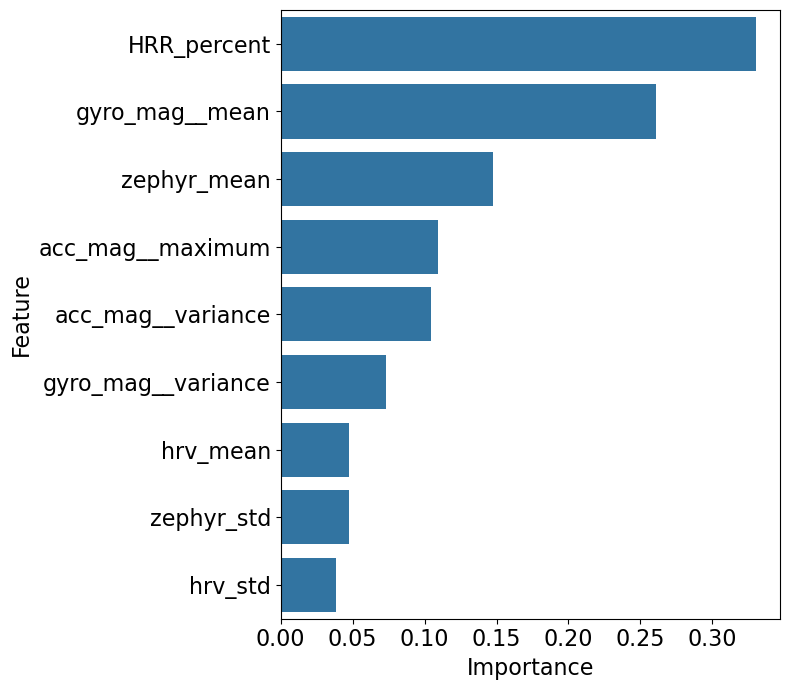

,feature,importance
2,HRR_percent,0.330457
7,gyro_mag__mean,0.260781
1,zephyr_mean,0.147259
5,acc_mag__maximum,0.109388
6,acc_mag__variance,0.104619
8,gyro_mag__variance,0.073505
3,hrv_mean,0.047697
0,zephyr_std,0.047488
4,hrv_std,0.038303


In [269]:
viz.set_feature_set("HR_IMU")
viz.plot_importance(
    top_n=15,
    save_path="IG_HR_IMU.png"
)

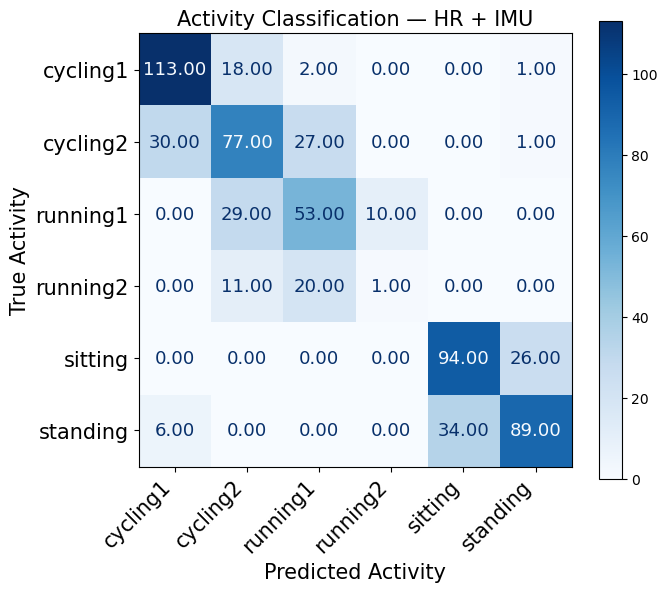

In [248]:
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    colorbar=True
)

# Axis labels
ax.set_xlabel("Predicted Activity", fontsize=15)
ax.set_ylabel("True Activity", fontsize=15)

# Activity names on both axes
ax.tick_params(
    axis="y",
    labelsize=15
)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=15
)

for text in disp.text_.ravel():
    text.set_fontsize(13)

ax.set_title(
    "Activity Classification — HR + IMU",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "activity_confusion_matrix_hr_imu.png",
    bbox_inches="tight"
)

plt.show()

In [ ]:
def plot_loss_curve(train_loss, val_loss):

    plt.figure(figsize=(6,4))

    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_loss, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    plt.show()

In [ ]:
for item in experiment.loss_storage:
    if item["Feature_Set"] == "HR_IMU":
        plot_loss_curve(
            item["Train_Loss"][1],
            item["Val_Loss"][1]
        )